In [24]:
pwd()

"/home/nicholaswallace/Documents/projects/Polyhedron"

In [25]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
include("Polyhedron.jl")
using .Poly

  Activating project at `~/Documents/projects/Polyhedron`


In [26]:
A = [0.9666 0;
    0.0328 0.9666] 
B = [0.1980;
    0.0033;;]

C = [0 1]

T = 0.5

delta = 0.5

A_exp = hcat(A, [0 0; 0 0])
A_exp = vcat(A_exp, [0 -T 1 T; 0 0 0 delta])

B_exp = vcat(B, [0;0])

E_exp = vcat(zeros(3), [1-delta])

Sx = [1/15 0
      0 1/15;
     -1/15 0;
      0 -1/15;]
Sv = [1/300;
      -1/300;]

Sw = [1/50;
      -1/50;]

Sx = vcat(Sx, zeros(4, 2))
Sv = vcat(vcat(zeros(4, 1), Sv) , zeros(2, 1))
Sw = vcat(zeros(6, 1), Sw)

S = hcat(hcat(Sx, Sv), Sw)

# Fr para a referência
R = [1/15;
      -1/15;;]
d = 1

1

testando variáveis

In [27]:
A_exp

4×4 Matrix{Float64}:
 0.9666   0.0     0.0  0.0
 0.0328   0.9666  0.0  0.0
 0.0     -0.5     1.0  0.5
 0.0      0.0     0.0  0.5

In [28]:
B_exp

4×1 Matrix{Float64}:
 0.198
 0.0033
 0.0
 0.0

In [29]:
E_exp

4-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.5

In [30]:
S

8×4 Matrix{Float64}:
  0.0666667   0.0         0.0          0.0
  0.0         0.0666667   0.0          0.0
 -0.0666667   0.0         0.0          0.0
  0.0        -0.0666667   0.0          0.0
  0.0         0.0         0.00333333   0.0
  0.0         0.0        -0.00333333   0.0
  0.0         0.0         0.0          0.02
  0.0         0.0         0.0         -0.02

In [31]:
R

2×1 Matrix{Float64}:
  0.06666666666666667
 -0.06666666666666667

tentando achar um poliedro p-invariante w.t. x(k+1) = Ax(k) BGx(k-d) + Er(k) 

In [32]:
result = Poly.finding_L_pinvariant_segref_delay(A_exp, B_exp, E_exp, S, R, d)

Job 18661716 dispatched
password: tsWydBOR
---------- Begin Solver Output -----------
Condor submit: 'neos.submit'
Condor submit: 'watchdog.submit'
Job submitted to NEOS HTCondor pool.

OTHER_LIMIT

Dict{String, Matrix{Float64}} with 2 entries:
  "G" => [-1.65134 -1.9417 0.0730366 0.0776656]
  "F" => [-4.17707e-5 -4.55249e-5 0.00333005 5.75782e-6; -0.000950049 -0.001051…

In [33]:
F = result["F"]

10×4 Matrix{Float64}:
 -4.17707e-5   -4.55249e-5   0.00333005    5.75782e-6
 -0.000950049  -0.00105139  -0.00330958   -1.15638e-5
 -0.269712     -0.282369     0.0103213    -0.000200503
  0.00460186    0.00561704  -0.000245005  -0.0644449
  0.24794       0.290997    -0.0106281    -0.0109862
  0.0455923     0.163199    -0.00536418    0.00768471
 -0.0172337    -0.188507     0.00530723    0.00526769
  0.0187165     0.210412    -0.00541393   -1.8394e-6
  0.016123      0.149358    -0.0035551     0.0137474
  0.000344492  -0.0337102    0.00170837    0.0344594

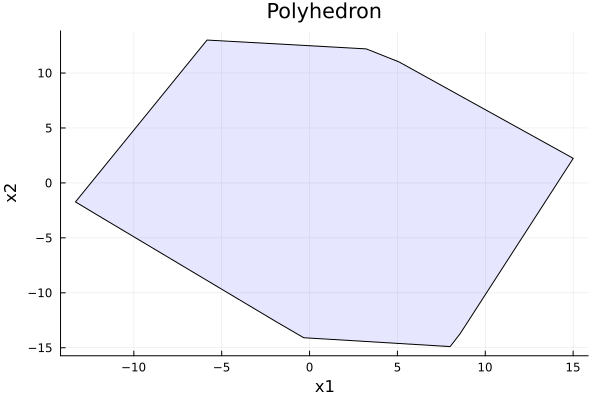

In [34]:
T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(10))

simulando trajetórias

In [35]:
G = result["G"]

1×4 Matrix{Float64}:
 -1.65134  -1.9417  0.0730366  0.0776656

testando se o sistema em malha fechada é estável (para d = 0)

In [36]:
using LinearAlgebra

eigvals(A_exp + B_exp*G)

4-element Vector{Float64}:
 0.5
 0.6742389992787219
 0.9374190151708175
 0.9881691221393994

simulando a trajetória 

In [37]:
using  Polyhedra, CDDLib, Base.Iterators

function get_extVert_tuple(init_cond_F, init_cond_w, i, n)
    hrep_ic = hrep(init_cond_F, init_cond_w)
    P = vrep(polyhedron(hrep_ic, CDDLib.Library()))

    ext_vertices = collect(points(P))
    vertice_alvo = ext_vertices[i]

    ext_vertices_tuple = Tuple[]

    for i in 1:n:length(vertice_alvo)
        estado = vertice_alvo[i : i + n - 1]
        push!(ext_vertices_tuple, Tuple(estado))
    end

    return ext_vertices_tuple
end

function trajectory_segref_delay(x0, A, BG, E, r, passos, d; varying=false, reverse=true)
    # Como o vetor vem na forma [x[k]...x[k-d]] para plotar a trajetória
    # é melhor que esteja na ordem cronológica [x[k-d]...x[k]]
    x0_traj = copy(x0)

    if reverse
        reverse!(x0_traj)
    end
    
    for i in 1:passos
        x_atual = collect(x0_traj[end])
        x_atrasado = collect(x0_traj[end - d])
        x_novo = A * x_atual + BG * x_atrasado + E * r[i]

        push!(x0_traj, Tuple(x_novo))   
    end

    return x0_traj[d+1:end]
end

trajectory_segref_delay (generic function with 1 method)

In [38]:
w = ones(size(F, 1))
nx = size(A_exp, 1)

passos = 100
r = ones(passos) # x2 ir para 1 

BG = B_exp * G

init_cond_F, init_cond_w = Poly.admissable_initCond(A_exp, BG, F, d, w; fixed_d=true)
ext_vertices_tuple = get_extVert_tuple(init_cond_F, init_cond_w, 2, nx)
traj1 = trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)


101-element Vector{Tuple}:
 (-5.808252063002466, 12.999162386511864, 300.4284426530627, -15.941033265194882)
 (-5.2992998842953005, 12.379728971132602, 285.9583448272093, -7.470516632597441)
 (-4.12137600259451, 11.809111108384641, 276.0332220253443, -3.2352583162987205)
 (-2.99005757724436, 11.296066738927221, 268.5110373130026, -1.1176291581493603)
 (-2.1406888355542826, 10.833195901623604, 262.3041893644643, -0.05881457907468013)
 (-1.568563731556436, 10.4094963329847, 256.85818412411516, 0.47059271046265994)
 (-1.1887848952844209, 10.01582674519526, 251.88873231285413, 0.73529635523133)
 (-0.916476919340719, 9.646182696681098, 247.24846711787217, 0.867648177615665)
 (-0.6938839257322793, 9.297139462732614, 242.85919985833945, 0.9338240888078325)
 (-0.4907177803448254, 8.96685545228446, 238.67754217137707, 0.9669120444039163)
 (-0.2953825503476414, 8.65424935791841, 234.6775704674368, 0.9834560222019582)
 (-0.10598339490842923, 8.358501104683492, 230.84217379957857, 0.99172801110097

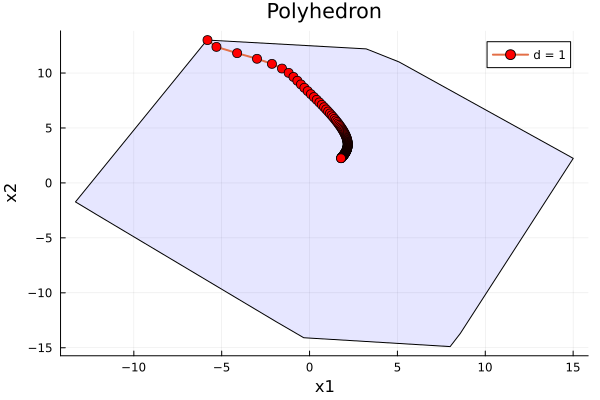

In [40]:
using Plots

T = Poly.poly_projection(F[:,3:4])
Poly.plot_poly(T*F[:,1:2], T*ones(10))

x1 = [p[1] for p in traj1]
x2 = [p[2] for p in traj1]
v = [p[3] for p in traj1]
w = [p[4] for p in traj1]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")
     


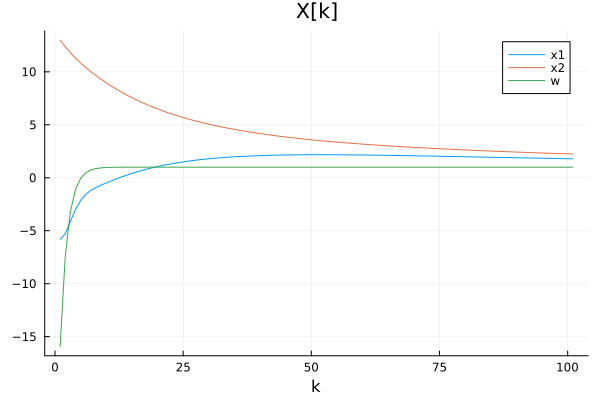

In [56]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

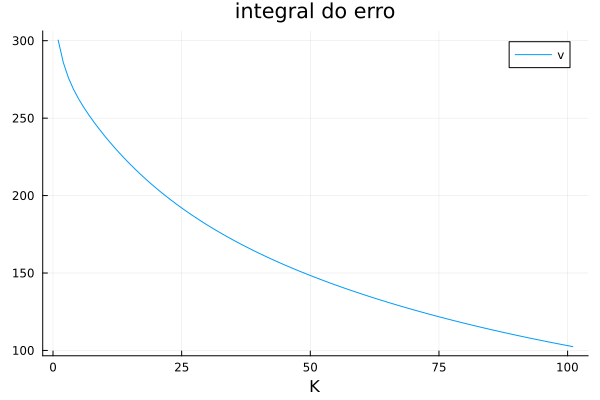

In [59]:
plot(v,
    label="v",
    xlabel="K",
    title="integral do erro")

simulando para outras referências

In [69]:
passos = 200
r = ones(passos)*5
traj5 = trajectory_segref_delay(ext_vertices_tuple, A_exp, BG, E_exp, r, passos, d; reverse=true)

201-element Vector{Tuple}:
 (-5.808252063002466, 12.999162386511864, 300.4284426530627, -15.941033265194882)
 (-5.2992998842953005, 12.379728971132602, 285.9583448272093, -5.470516632597441)
 (-4.12137600259451, 11.809111108384641, 277.0332220253443, -0.23525831629872052)
 (-2.95930198659099, 11.296579332104777, 271.0110373130026, 2.3823708418506397)
 (-2.05036584661119, 10.835710068146087, 266.5539330678755, 3.69118542092532)
 (-1.4015352035289295, 10.41621782583125, 262.9816707442651, 4.34559271046266)
 (-0.9387108515461875, 10.029279347042486, 259.9463581865808, 4.6727963552313305)
 (-0.583809770497283, 9.668904169897342, 257.26811669067524, 4.836398177615665)
 (-0.28219191239777763, 9.331515787013208, 254.85186369453442, 4.918199088807833)
 (-0.004355010730212938, 9.015060793196877, 252.64520534543172, 4.959099544403916)
 (0.2616103410543986, 8.718245249925921, 250.61722472103523, 4.979549772201958)
 (0.5182302804365713, 8.440059306511202, 248.74787698217324, 4.989774886100979)
 (0

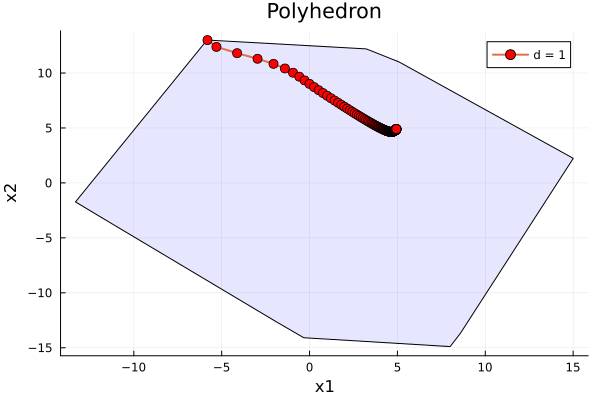

In [70]:
Poly.plot_poly(T*F[:,1:2], T*ones(10))

x1 = [p[1] for p in traj5]
x2 = [p[2] for p in traj5]
v = [p[3] for p in traj5]
w = [p[4] for p in traj5]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")

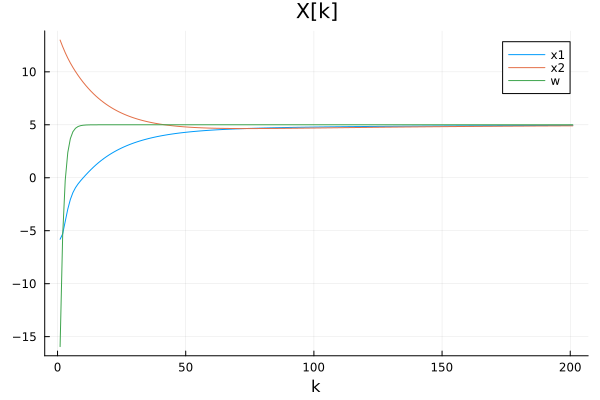

In [71]:
plot(hcat(hcat(x1, x2), w), 
     label=["x1" "x2" "w"], 
     xlabel="k",  
     title="X[k]")

alterando a referência no meio da simulação 

In [68]:
passos = 100
r = vcat(r, ones(passos)*10)
traj5 = trajectory_segref_delay(traj5, A_exp, BG, E_exp, r, passos, d; reverse=true)

300-element Vector{Tuple}:
 (4.943207696192016, 4.9027432253945165, 248.2583037471993, 5.0)
 (4.942448536816178, 4.901579727269317, 248.20909361083397, 5.0)
 (4.941680206746499, 4.900402381893698, 248.15929480178082, 5.0)
 (4.940902590932057, 4.899211029248844, 248.10890031640523, 5.0)
 (4.940115572597226, 4.898005507786739, 248.0579030702986, 5.0)
 (4.939319033197963, 4.896785654437593, 248.0062958975174, 5.0)
 (4.938512852376041, 4.895551304619082, 247.95407154982692, 5.0)
 (4.937696907911104, 4.894302292247511, 247.90122269595068, 5.0)
 (4.936871075670399, 4.893038449751073, 247.84774192082622, 5.0)
 (4.936035229556047, 4.891759608085326, 247.7936217248689, 5.0)
 (4.935189241449703, 4.890465596751082, 247.73885452324444, 5.0)
 (4.934332981154437, 4.8891562438148695, 247.68343264515187, 5.0)
 (4.933466316333664, 4.887831375932153, 247.62734833311794, 5.0)
 ⋮
 (4.742138574481353, 4.662613544504463, 237.11911403916173, 5.0)
 (4.746581869453502, 4.665138242750333, 237.2878072669095, 5.0

In [73]:
vcat(r, ones(100)*10)

300-element Vector{Float64}:
  5.0
  5.0
  5.0
  5.0
  5.0
  5.0
  5.0
  5.0
  5.0
  5.0
  5.0
  5.0
  5.0
  ⋮
 10.0
 10.0
 10.0
 10.0
 10.0
 10.0
 10.0
 10.0
 10.0
 10.0
 10.0
 10.0

In [ ]:
Poly.plot_poly(T*F[:,1:2], T*ones(10))

x1 = [p[1] for p in traj5]
x2 = [p[2] for p in traj5]
v = [p[3] for p in traj5]
w = [p[4] for p in traj5]

# Plot as connected trajectory with markers
plot!(x1, x2,
     seriestype = :path,          # connects points with lines
     linewidth = 2,
     marker = :circle,
     markersize = 5,
     markercolor = :red,
     label = "d = 1",
     xlabel = "x1",
     ylabel = "x2")